In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder


In [ ]:


# 1. 创建 3×4 的标准正态分布随机矩阵 X
X = np.random.randn(3, 4)
print("矩阵 X (3×4):")
print(X)

# 2. 创建 4×2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("\n矩阵 Y (4×2):")
print(Y)

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)
print("\n矩阵 Z = X × Y (3×2):")
print(Z)

# 4. 输出指定元素
# 第一行和第二列交叉处的元素（索引从0开始）
z_01 = Z[0, 1]
# 第2行所有元素（索引为1）
z_row1 = Z[1, :]
print("\nZ 的第一行第二列元素:", z_01)
print("Z 的第2行所有元素:", z_row1)

# 5. 计算 Z 的 Frobenius 范数
frobenius_norm = np.linalg.norm(Z, ord='fro')
print("\nZ 的 Frobenius 范数:", frobenius_norm)

矩阵 X (3×4):
[[ 0.71354423  0.65197296 -0.1745306  -0.90097317]
 [-0.09918734  0.47112441  1.48743095  0.47747944]
 [ 0.65145903 -0.75494593 -0.03263769 -0.23278226]]

矩阵 Y (4×2):
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

矩阵 Z = X × Y (3×2):
[[ 0.29001341  0.29001341]
 [ 2.33684745  2.33684745]
 [-0.36890685 -0.36890685]]

Z 的第一行第二列元素: 0.29001340521270247
Z 的第2行所有元素: [2.33684745 2.33684745]

Z 的 Frobenius 范数: 3.370773222775379


d:\Anaconda2023-64\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda2023-64\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda2023-64\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda2023-64\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda2023-64\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda2023-64\L

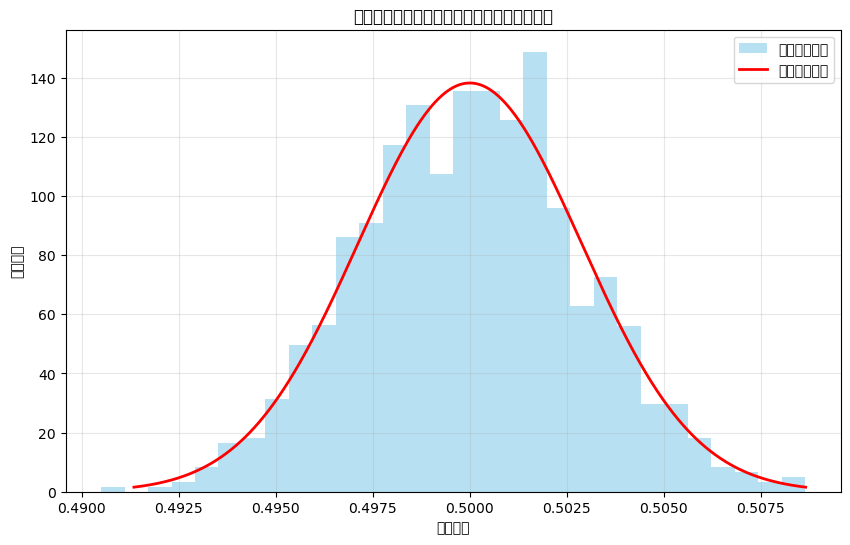

理论均值: 0.5
模拟均值的实际均值: 0.500009
理论方差（均值的方差）: 0.00000833
模拟均值的实际方差: 0.00000820


In [3]:


# 1. 参数设置与模拟
n = 10000  # 每次样本数量
m = 1000   # 重复次数
means = []

for _ in range(m):
    # 生成 n 个 U(0,1) 的随机变量
    samples = np.random.uniform(0, 1, size=n)
    # 计算均值并保存
    sample_mean = np.mean(samples)
    means.append(sample_mean)

means = np.array(means)

# 理论分布参数：U(0,1)的均值μ=0.5，方差σ²=1/12
mu_theory = 0.5
var_theory = 1/12
# 均值的理论方差：σ²/n
var_mean_theory = var_theory / n
std_mean_theory = np.sqrt(var_mean_theory)

# 2. 绘制直方图 + 理论正态曲线
plt.figure(figsize=(10, 6))
# 直方图（density=True 转为概率密度）
plt.hist(means, bins=30, density=True, alpha=0.6, color='skyblue', label='模拟均值分布')

# 理论正态分布曲线
x = np.linspace(mu_theory - 3*std_mean_theory, 
                mu_theory + 3*std_mean_theory, 1000)
y = norm.pdf(x, loc=mu_theory, scale=std_mean_theory)
plt.plot(x, y, 'r-', lw=2, label='理论正态分布')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理模拟：均匀分布样本均值的分布')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. 计算实际方差
actual_mean = np.mean(means)
actual_var = np.var(means, ddof=0)  # 总体方差

print(f"理论均值: {mu_theory}")
print(f"模拟均值的实际均值: {actual_mean:.6f}")
print(f"理论方差（均值的方差）: {var_mean_theory:.8f}")
print(f"模拟均值的实际方差: {actual_var:.8f}")

In [5]:
# 给定数值
x = 2
w1 = 1.5
w2 = 0.5

# ======================
# 1. 前向传播
# ======================
a = x * w1
b = a + w2
L = b ** 2

print("=== 前向计算结果 ===")
print(f"a = {a}")
print(f"b = {b}")
print(f"L = {L}")

# ======================
# 2. 反向传播（手动求导）
# ======================
# 链式法则梯度
dL_db = 2 * b
db_dw2 = 1
db_da = 1
da_dw1 = x

# 最终梯度
dL_dw2 = dL_db * db_dw2
dL_dw1 = dL_db * db_da * da_dw1

print("\n=== 反向传播梯度结果 ===")
print(f"∂L/∂w1 = {dL_dw1}")
print(f"∂L/∂w2 = {dL_dw2}")

=== 前向计算结果 ===
a = 3.0
b = 3.5
L = 12.25

=== 反向传播梯度结果 ===
∂L/∂w1 = 14.0
∂L/∂w2 = 7.0


In [7]:

# ----------------------
# 1. 加载数据
# ----------------------
digits = load_digits()
X = digits.data  # 已经是展平后的向量 (1797, 64)
y = digits.target.reshape(-1, 1)  # (1797, 1)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------
# 2. 数据预处理
# ----------------------
# 归一化到 [0, 1]
X_train = X_train / 16.0
X_test = X_test / 16.0

# 标签 one-hot 编码
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)
y_test_onehot = encoder.transform(y_test)

# 超参数设置
n_features = X_train.shape[1]  # 64
n_classes = 10
lr = 0.1
batch_size = 32
epochs = 50

# 初始化权重和偏置
np.random.seed(42)
W = np.random.randn(n_features, n_classes) * 0.01
b = np.zeros((1, n_classes))

# ----------------------
# 3. 实现 softmax 和交叉熵损失
# ----------------------
def softmax(z):
    # 数值稳定的 softmax
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    # 交叉熵损失
    m = y_pred.shape[0]
    log_likelihood = -np.log(y_pred[range(m), y_true.argmax(axis=1)])
    return np.sum(log_likelihood) / m

# ----------------------
# 4. 训练模型（小批量 SGD）
# ----------------------
n_samples = X_train.shape[0]
loss_history = []

for epoch in range(epochs):
    # 打乱数据
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]
    
    epoch_loss = 0.0
    for i in range(0, n_samples, batch_size):
        # 取一个 batch
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        m_batch = X_batch.shape[0]
        
        # 前向传播
        z = np.dot(X_batch, W) + b
        y_pred = softmax(z)
        
        # 计算损失
        batch_loss = cross_entropy_loss(y_pred, y_batch)
        epoch_loss += batch_loss
        
        # 反向传播（梯度计算）
        dz = y_pred - y_batch
        dW = np.dot(X_batch.T, dz) / m_batch
        db = np.sum(dz, axis=0, keepdims=True) / m_batch
        
        # 更新参数
        W -= lr * dW
        b -= lr * db
    
    # 记录平均损失
    avg_epoch_loss = epoch_loss / (n_samples // batch_size)
    loss_history.append(avg_epoch_loss)
    
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_epoch_loss:.4f}")

# ----------------------
# 5. 测试集准确率计算
# ----------------------
def predict(X, W, b):
    z = np.dot(X, W) + b
    y_pred_proba = softmax(z)
    return np.argmax(y_pred_proba, axis=1)

y_pred_test = predict(X_test, W, b)
y_true_test = y_test.flatten()
accuracy = np.mean(y_pred_test == y_true_test)

print(f"\n测试集准确率: {accuracy * 100:.2f}%")

Epoch 5/50, Loss: 0.7533
Epoch 10/50, Loss: 0.4677
Epoch 15/50, Loss: 0.3631
Epoch 20/50, Loss: 0.3072
Epoch 25/50, Loss: 0.2715
Epoch 30/50, Loss: 0.2459
Epoch 35/50, Loss: 0.2276
Epoch 40/50, Loss: 0.2126
Epoch 45/50, Loss: 0.2003
Epoch 50/50, Loss: 0.1901

测试集准确率: 95.83%


Epoch 100/1000, Loss: 0.0324
Epoch 200/1000, Loss: 0.0208
Epoch 300/1000, Loss: 0.0163
Epoch 400/1000, Loss: 0.0139
Epoch 500/1000, Loss: 0.0122
Epoch 600/1000, Loss: 0.0111
Epoch 700/1000, Loss: 0.0102
Epoch 800/1000, Loss: 0.0095
Epoch 900/1000, Loss: 0.0090
Epoch 1000/1000, Loss: 0.0085

测试集准确率: 100.00%


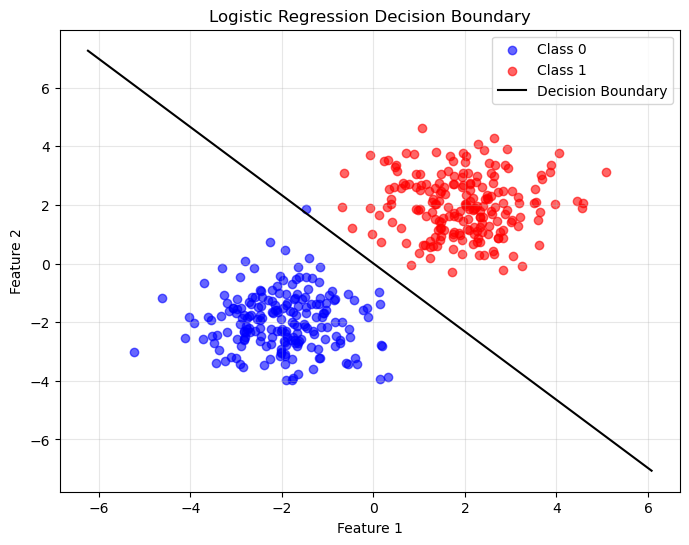

In [8]:


# ----------------------
# 1. 生成线性可分数据
# ----------------------
np.random.seed(42)
n_samples_per_class = 200

# 类别0：均值(-2, -2)，协方差矩阵为对角阵
X0 = np.random.randn(n_samples_per_class, 2) + np.array([-2, -2])
y0 = np.zeros((n_samples_per_class, 1))

# 类别1：均值(2, 2)，协方差矩阵为对角阵
X1 = np.random.randn(n_samples_per_class, 2) + np.array([2, 2])
y1 = np.ones((n_samples_per_class, 1))

# 合并数据
X_train = np.vstack((X0, X1))
y_train = np.vstack((y0, y1))

# ----------------------
# 2. 定义 sigmoid 函数和二元交叉熵损失
# ----------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    m = y_true.shape[0]
    # 避免 log(0)，加上极小值
    epsilon = 1e-7
    loss = -(1/m) * np.sum(y_true * np.log(y_pred + epsilon) + (1 - y_true) * np.log(1 - y_pred + epsilon))
    return loss

# ----------------------
# 3. 梯度下降训练参数 w, b
# ----------------------
# 初始化参数
n_features = X_train.shape[1]
w = np.zeros((n_features, 1))
b = 0.0
lr = 0.1
epochs = 1000
m = X_train.shape[0]
loss_history = []

for epoch in range(epochs):
    # 前向传播
    z = np.dot(X_train, w) + b
    y_pred = sigmoid(z)
    
    # 计算损失
    loss = binary_cross_entropy(y_pred, y_train)
    loss_history.append(loss)
    
    # 反向传播：计算梯度
    dw = (1/m) * np.dot(X_train.T, (y_pred - y_train))
    db = (1/m) * np.sum(y_pred - y_train)
    
    # 更新参数
    w -= lr * dw
    b -= lr * db
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}")

# ----------------------
# 4. 绘制决策边界 + 测试集评估
# ----------------------
# 生成测试集（每类50个样本，共100个）
X0_test = np.random.randn(50, 2) + np.array([-2, -2])
X1_test = np.random.randn(50, 2) + np.array([2, 2])
X_test = np.vstack((X0_test, X1_test))
y_test = np.vstack((np.zeros((50,1)), np.ones((50,1))))

# 预测函数
def predict(X, w, b):
    z = np.dot(X, w) + b
    y_pred_proba = sigmoid(z)
    return (y_pred_proba > 0.5).astype(int)

# 计算测试集准确率
y_pred_test = predict(X_test, w, b)
accuracy = np.mean(y_pred_test == y_test)
print(f"\n测试集准确率: {accuracy * 100:.2f}%")

# 绘制决策边界
plt.figure(figsize=(8, 6))
# 绘制训练数据点
plt.scatter(X_train[:n_samples_per_class, 0], X_train[:n_samples_per_class, 1], 
            c='blue', label='Class 0', alpha=0.6)
plt.scatter(X_train[n_samples_per_class:, 0], X_train[n_samples_per_class:, 1], 
            c='red', label='Class 1', alpha=0.6)

# 决策边界：w1*x1 + w2*x2 + b = 0 → x2 = (-w1*x1 - b)/w2
x1 = np.linspace(X_train[:,0].min()-1, X_train[:,0].max()+1, 100)
x2 = (-w[0,0] * x1 - b) / w[1,0]
plt.plot(x1, x2, 'k-', label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()